In [1]:
# CELL 1: Install dependencies
!pip install -q --upgrade pip
!pip install -q sentence-transformers numpy pandas scikit-learn matplotlib torch tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.8 MB/s eta 0:00:00


In [2]:
# CELL 2: Imports & Environment Verification
import os
import sys
import time
import random
from typing import List, Dict, Any, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import sklearn
import sentence_transformers
import matplotlib.pyplot as plt

# Thiết lập seed để đảm bảo tính tái lập (Reproducibility)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=== RUNTIME ENVIRONMENT ===")
print(f"Python Version       : {sys.version.split()[0]}")
print(f"PyTorch Version      : {torch.__version__}")
print(f"SentenceTransformers : {sentence_transformers.__version__}")
print(f"Pandas Version       : {pd.__version__}")
print(f"Scikit-Learn Version : {sklearn.__version__}")
device_name = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Compute Device       : {device_name}")
if device_name == "cuda":
    print(f"GPU Model            : {torch.cuda.get_device_name(0)}")

=== RUNTIME ENVIRONMENT ===
Python Version       : 3.13.15
PyTorch Version      : 2.11.0+cpu
SentenceTransformers : 5.7.0
Pandas Version       : 2.2.3
Scikit-Learn Version : 1.6.1
Compute Device       : cpu


In [3]:
# CELL 3: Configuration
class Config:
    SEED: int = 42
    # Model đa ngữ nhỏ gọn, chất lượng cao cho tiếng Việt + tiếng Anh
    MODEL_NAME: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    BATCH_SIZE: int = 16
    EMBEDDING_NORMALIZE: bool = True

    # RRF Parameters
    RRF_K: int = 60
    W_SEMANTIC: float = 1.0
    W_KEYWORD: float = 0.5
    KW_MIN_THRESHOLD: float = 0.25
    SEMANTIC_AGREEMENT_DEPTH: int = 10

    REC_WEIGHT_CONTENT: float = 0.7
    REC_WEIGHT_POPULARITY: float = 0.3
    TOP_K_DEFAULT: int = 5

cfg = Config()
print(f"Configuration loaded: Model = {cfg.MODEL_NAME} on {cfg.DEVICE}")

Configuration loaded: Model = sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 on cpu


In [4]:
# CELL 4: Load / Generate Dataset
# Ghi chú: Đây là dữ liệu demo tổng hợp (Synthetic Data) nhằm mục đích PoC kiểm thử thuật toán.

raw_books = [
    # Programming / Python
    {"book_id": 101, "title": "Python Crash Course", "author": "Eric Matthes", "category": "Programming", "publisher": "No Starch Press", "description": "A hands-on, project-based introduction to programming in Python for beginners."},
    {"book_id": 102, "title": "Automate the Boring Stuff with Python", "author": "Al Sweigart", "category": "Programming", "publisher": "No Starch Press", "description": "Practical programming for total beginners. Learn how to use Python to write programs that automate tasks."},
    {"book_id": 103, "title": "Effective Python: 90 Specific Ways to Write Better Python", "author": "Brett Slatkin", "category": "Programming", "publisher": "Addison-Wesley", "description": "Idiomatic Python techniques, design patterns, best practices, and code optimization."},
    {"book_id": 104, "title": "Fluent Python", "author": "Luciano Ramalho", "category": "Programming", "publisher": "O'Reilly Media", "description": "Clear guide through Python's best language features, data model, generators, and metaprogramming."},
    {"book_id": 105, "title": "Lập Trình Python Cơ Bản Đến Nâng Cao", "author": "Nguyễn Văn A", "category": "Programming", "publisher": "NXB Khoa Học Kỹ Thuật", "description": "Giáo trình toàn diện học lập trình Python, cú pháp cơ bản, xử lý dữ liệu và thuật toán cho sinh viên."},

    # Software Engineering
    {"book_id": 106, "title": "Clean Code: A Handbook of Agile Software Craftsmanship", "author": "Robert C. Martin", "category": "Software Engineering", "publisher": "Prentice Hall", "description": "How to write clean, maintainable software and professional design principles."},
    {"book_id": 107, "title": "Design Patterns: Elements of Reusable Object-Oriented Software", "author": "Erich Gamma, Richard Helm, Ralph Johnson, John Vlissides", "category": "Software Engineering", "publisher": "Addison-Wesley", "description": "Classic software engineering design patterns, object-oriented solutions, and software architectures."},
    {"book_id": 108, "title": "Building Microservices", "author": "Sam Newman", "category": "Software Engineering", "publisher": "O'Reilly Media", "description": "Designing fine-grained systems, distributed systems architecture, service integration, and deployment."},
    {"book_id": 109, "title": "Refactoring: Improving the Design of Existing Code", "author": "Martin Fowler", "category": "Software Engineering", "publisher": "Addison-Wesley", "description": "Techniques for restructuring existing computer code without changing its external behavior."},

    # Artificial Intelligence / Machine Learning / Deep Learning
    {"book_id": 110, "title": "Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow", "author": "Aurélien Géron", "category": "Machine Learning", "publisher": "O'Reilly Media", "description": "Practical concepts and tools for building intelligent systems, training models, and neural networks."},
    {"book_id": 111, "title": "Deep Learning", "author": "Ian Goodfellow, Yoshua Bengio, Aaron Courville", "category": "Deep Learning", "publisher": "MIT Press", "description": "Comprehensive mathematical and conceptual textbook on deep neural networks, generative modeling, and optimization."},
    {"book_id": 112, "title": "Pattern Recognition and Machine Learning", "author": "Christopher M. Bishop", "category": "Machine Learning", "publisher": "Springer", "description": "Comprehensive statistical machine learning reference covering Bayesian models and probabilistic inference."},
    {"book_id": 113, "title": "Artificial Intelligence: A Modern Approach", "author": "Stuart Russell, Peter Norvig", "category": "Artificial Intelligence", "publisher": "Pearson", "description": "The definitive university textbook covering AI fundamentals, search algorithms, logic, and intelligent agents."},
    {"book_id": 114, "title": "Nhập Môn Học Máy và Trí Tuệ Nhân Tạo", "author": "Trần Văn B", "category": "Artificial Intelligence", "publisher": "NXB Đại Học Quốc Gia", "description": "Tài liệu cơ bản về thuật toán machine learning, hồi quy, phân loại, mạng nơ-ron và ứng dụng thực tiễn."},

    # Database
    {"book_id": 115, "title": "Database System Concepts", "author": "Abraham Silberschatz, Henry F. Korth, S. Sudarshan", "category": "Database", "publisher": "McGraw-Hill", "description": "Fundamental concepts of database management, SQL, relational design, indexing, transactions, and concurrency."},
    {"book_id": 116, "title": "Designing Data-Intensive Applications", "author": "Martin Kleppmann", "category": "Database", "publisher": "O'Reilly Media", "description": "The big ideas behind reliable, scalable, and maintainable distributed data systems, storage engines, and replication."},
    {"book_id": 117, "title": "High Performance MySQL", "author": "Silvia Botros, Jeremy Tinley", "category": "Database", "publisher": "O'Reilly Media", "description": "Optimization, backup, replication, indexing strategies, and database architecture tuning for MySQL."},

    # Business
    {"book_id": 118, "title": "The Lean Startup", "author": "Eric Ries", "category": "Business", "publisher": "Crown Business", "description": "How constant innovation creates radically successful businesses, agile entrepreneurship, and validation."},
    {"book_id": 119, "title": "Good to Great: Why Some Companies Make the Leap and Others Don't", "author": "Jim Collins", "category": "Business", "publisher": "HarperBusiness", "description": "Management study of company culture, disciplined people, disciplined thought, and long-term corporate success."},
    {"book_id": 120, "title": "Zero to One: Notes on Startups, or How to Build the Future", "author": "Peter Thiel, Blake Masters", "category": "Business", "publisher": "Currency", "description": "Philosophy on technology progress, building monopolies, startup execution, and future investments."},

    # History & Literature
    {"book_id": 121, "title": "Sapiens: A Brief History of Humankind", "author": "Yuval Noah Harari", "category": "History", "publisher": "Harper", "description": "Survey of the history of humankind from the archaic human species in the Stone Age up to the twenty-first century."},
    {"book_id": 122, "title": "Guns, Germs, and Steel: The Fates of Human Societies", "author": "Jared Diamond", "category": "History", "publisher": "W. W. Norton", "description": "Transdisciplinary explanation of why Eurasian and North African civilizations survived and conquered others."},
    {"book_id": 123, "title": "Đắc Nhân Tâm (How to Win Friends and Influence People)", "author": "Dale Carnegie", "category": "Literature", "publisher": "NXB Tổng Hợp TP.HCM", "description": "Nghệ thuật giao tiếp, thấu hiểu con người, tạo thiện cảm và kỹ năng ứng xử kinh điển trong cuộc sống."},
    {"book_id": 124, "title": "Nhà Giả Kim (The Alchemist)", "author": "Paulo Coelho", "category": "Literature", "publisher": "NXB Hội Nhà Văn", "description": "Tiểu thuyết triết lý về hành trình theo đuổi ước mơ, lắng nghe tiếng gọi trái tim và định mệnh của chàng chăn cừu Santiago."}
]

df_books = pd.DataFrame(raw_books)
print(f"Loaded synthetic books dataset: {len(df_books)} books.")
display(df_books.head(3))

Loaded synthetic books dataset: 24 books.


,book_id,title,author,category,publisher,description
0,101,Python Crash Course,Eric Matthes,Programming,No Starch Press,"A hands-on, project-based introduction to prog..."
1,102,Automate the Boring Stuff with Python,Al Sweigart,Programming,No Starch Press,Practical programming for total beginners. Lea...
2,103,Effective Python: 90 Specific Ways to Write Be...,Brett Slatkin,Programming,Addison-Wesley,"Idiomatic Python techniques, design patterns, ..."


In [5]:
# CELL 5: Data Validation & Cleaning
def validate_and_clean_books(df: pd.DataFrame) -> pd.DataFrame:
    """Tự động kiểm tra schema tối thiểu, chuẩn hóa tên cột và xử lý dữ liệu khuyết."""
    df_clean = df.copy()

    # Bắt buộc phải có book_id và title
    required_cols = ["book_id", "title"]
    for col in required_cols:
        if col not in df_clean.columns:
            raise ValueError(f"Missing mandatory column: '{col}'")

    # Kiểm tra trùng lặp ID
    if df_clean["book_id"].duplicated().any():
        raise ValueError("Duplicate 'book_id' detected in dataset.")

    # Các trường mở rộng: điền giá trị mặc định nếu thiếu
    optional_cols = {
        "author": "Unknown Author",
        "category": "General",
        "publisher": "Unknown Publisher",
        "description": ""
    }
    for col, default_val in optional_cols.items():
        if col not in df_clean.columns:
            df_clean[col] = default_val
        else:
            df_clean[col] = df_clean[col].fillna(default_val).astype(str).str.strip()

    df_clean["title"] = df_clean["title"].astype(str).str.strip()
    return df_clean

df_books = validate_and_clean_books(df_books)
print(f"Validation successful. Cleaned books count: {len(df_books)}")

Validation successful. Cleaned books count: 24


In [6]:
# CELL 6: Build Book Documents
def construct_book_document(row: pd.Series) -> str:
    """Ghép nối các trường metadata thành một định dạng văn bản có cấu trúc rõ ràng."""
    return (
        f"Title: {row['title']}\n"
        f"Author: {row['author']}\n"
        f"Category: {row['category']}\n"
        f"Publisher: {row['publisher']}\n"
        f"Description: {row['description']}"
    ).strip()

df_books["document_text"] = df_books.apply(construct_book_document, axis=1)

print("Sample structured document for indexing:")
print("-" * 50)
print(df_books["document_text"].iloc[0])
print("-" * 50)

Sample structured document for indexing:
--------------------------------------------------
Title: Python Crash Course
Author: Eric Matthes
Category: Programming
Publisher: No Starch Press
Description: A hands-on, project-based introduction to programming in Python for beginners.
--------------------------------------------------


In [7]:
# CELL 7: Load Lightweight Multilingual Embedding Model
from sentence_transformers import SentenceTransformer
import time

class EmbeddingService:
    def __init__(self, model_name: str, device: str = "cpu"):
        print(f"Loading lightweight model: '{model_name}' on {device}...")
        t0 = time.time()
        self.device = device
        self.model = SentenceTransformer(model_name, device=device)
        self.dimension = self.model.get_sentence_embedding_dimension()
        print(f"Model loaded successfully in {time.time() - t0:.2f}s.")
        print(f"-> Embedding Dimension: {self.dimension} (Lighter & faster for pgvector)")

    def embed_texts(self, texts: list, batch_size: int = 16, normalize: bool = True) -> np.ndarray:
        return self.model.encode(
            texts,
            batch_size=batch_size,
            show_progress_bar=False,
            normalize_embeddings=normalize,
            convert_to_numpy=True,
            device=self.device
        )

    def embed_query(self, query: str, normalize: bool = True) -> np.ndarray:
        return self.embed_texts([query], batch_size=1, normalize=normalize)[0]

# Khởi tạo dịch vụ
embedding_service = EmbeddingService(model_name=cfg.MODEL_NAME, device=cfg.DEVICE)

Loading lightweight model: 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2' on cpu...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully in 19.76s.
-> Embedding Dimension: 384 (Lighter & faster for pgvector)


/tmp/ipykernel_951/2708503147.py:11: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dimension = self.model.get_sentence_embedding_dimension()


In [8]:
# CELL 8: Generate Book Embeddings
start_time = time.time()

book_embeddings = embedding_service.embed_texts(
    texts=df_books["document_text"].tolist(),
    batch_size=cfg.BATCH_SIZE,
    normalize=cfg.EMBEDDING_NORMALIZE
)

elapsed_embedding = time.time() - start_time

print("=== EMBEDDING GENERATION SUMMARY ===")
print(f"Books Processed     : {len(df_books)}")
print(f"Embedding Dimension : {book_embeddings.shape[1]}")
print(f"Device Used         : {cfg.DEVICE}")
print(f"Total Indexing Time : {elapsed_embedding:.3f} seconds")
print(f"Average Speed       : {elapsed_embedding / len(df_books) * 1000:.2f} ms/book")

=== EMBEDDING GENERATION SUMMARY ===
Books Processed     : 24
Embedding Dimension : 384
Device Used         : cpu
Total Indexing Time : 2.175 seconds
Average Speed       : 90.61 ms/book


In [9]:
# CELL 9: Semantic Search Implementation
class SemanticSearchEngine:
    def __init__(self, df: pd.DataFrame, embeddings: np.ndarray, embed_service: EmbeddingService):
        self.df = df.copy().reset_index(drop=True)
        self.embeddings = embeddings
        self.embed_service = embed_service

    def search(self, query: str, top_k: int = 5) -> pd.DataFrame:
        query_vec = self.embed_service.embed_query(query, normalize=True)
        # Cosine similarity vì cả 2 vector đều đã L2-normalized
        similarities = np.dot(self.embeddings, query_vec)

        top_indices = np.argsort(similarities)[::-1][:top_k]

        results = []
        for rank, idx in enumerate(top_indices, 1):
            results.append({
                "rank": rank,
                "book_id": self.df.iloc[idx]["book_id"],
                "title": self.df.iloc[idx]["title"],
                "category": self.df.iloc[idx]["category"],
                "similarity": float(similarities[idx])
            })
        return pd.DataFrame(results)

semantic_search_engine = SemanticSearchEngine(df_books, book_embeddings, embedding_service)

# Kiểm thử với câu query tiếng Việt đa ngữ
sample_query = "sách học lập trình Python cho người mới"
print(f"Testing Semantic Search for: '{sample_query}'")
display(semantic_search_engine.search(sample_query, top_k=5))

Testing Semantic Search for: 'sách học lập trình Python cho người mới'


,rank,book_id,title,category,similarity
0,1,105,Lập Trình Python Cơ Bản Đến Nâng Cao,Programming,0.749415
1,2,102,Automate the Boring Stuff with Python,Programming,0.666600
2,3,101,Python Crash Course,Programming,0.656633
3,4,104,Fluent Python,Programming,0.641094
4,5,103,Effective Python: 90 Specific Ways to Write Be...,Programming,0.615850


In [10]:
# CELL 10: Keyword Search (TF-IDF Baseline)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

class KeywordSearchEngine:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy().reset_index(drop=True)
        # Kết hợp title, author, category, publisher, description làm corpus
        self.corpus = (
            self.df["title"] + " " +
            self.df["author"] + " " +
            self.df["category"] + " " +
            self.df["publisher"] + " " +
            self.df["description"]
        ).tolist()

        self.vectorizer = TfidfVectorizer(lowercase=True, token_pattern=r"(?u)\b\w+\b")
        self.tfidf_matrix = self.vectorizer.fit_transform(self.corpus)

    def search(self, query: str, top_k: int = 5) -> pd.DataFrame:
        query_vec = self.vectorizer.transform([query])
        scores = cosine_similarity(self.tfidf_matrix, query_vec).flatten()
        top_indices = np.argsort(scores)[::-1][:top_k]

        results = []
        for rank, idx in enumerate(top_indices, 1):
            results.append({
                "rank": rank,
                "book_id": self.df.iloc[idx]["book_id"],
                "title": self.df.iloc[idx]["title"],
                "category": self.df.iloc[idx]["category"],
                "score": float(scores[idx])
            })
        return pd.DataFrame(results)

keyword_search_engine = KeywordSearchEngine(df_books)
print(f"Testing Keyword Search for: '{sample_query}'")
display(keyword_search_engine.search(sample_query, top_k=5))

Testing Keyword Search for: 'sách học lập trình Python cho người mới'


,rank,book_id,title,category,score
0,1,105,Lập Trình Python Cơ Bản Đến Nâng Cao,Programming,0.519110
1,2,103,Effective Python: 90 Specific Ways to Write Be...,Programming,0.140685
2,3,114,Nhập Môn Học Máy và Trí Tuệ Nhân Tạo,Artificial Intelligence,0.114415
3,4,101,Python Crash Course,Programming,0.102510
4,5,104,Fluent Python,Programming,0.101549


In [11]:
# CELL 11: Hybrid Search with Semantic Agreement Gating
class HybridSearchEngine:
    def __init__(
        self,
        semantic_engine: SemanticSearchEngine,
        keyword_engine: KeywordSearchEngine,
        rrf_k: int = 60,
        w_semantic: float = 1.0,
        w_keyword: float = 0.5,
        kw_min_threshold: float = 0.30,   # Ngưỡng cosine TF-IDF chặt chẽ
        semantic_agreement_depth: int = 10 # Chỉ chấp nhận keyword nếu semantic cũng đánh giá trong top 10
    ):
        self.semantic_engine = semantic_engine
        self.keyword_engine = keyword_engine
        self.rrf_k = rrf_k
        self.w_sem = w_semantic
        self.w_kw = w_keyword
        self.kw_min_threshold = kw_min_threshold
        self.semantic_agreement_depth = semantic_agreement_depth

    def search(self, query: str, top_k: int = 5) -> pd.DataFrame:
        n_books = len(self.semantic_engine.df)

        # 1. Semantic Ranking
        query_vec = self.semantic_engine.embed_service.embed_query(query, normalize=True)
        sem_scores = np.dot(self.semantic_engine.embeddings, query_vec)
        sem_ranked_indices = np.argsort(sem_scores)[::-1]
        sem_rank_map = {idx: rank for rank, idx in enumerate(sem_ranked_indices, start=1)}

        # 2. Keyword Ranking
        query_tfidf = self.keyword_engine.vectorizer.transform([query])
        kw_scores = cosine_similarity(self.keyword_engine.tfidf_matrix, query_tfidf).flatten()
        kw_ranked_indices = np.argsort(kw_scores)[::-1]
        kw_rank_map = {idx: rank for rank, idx in enumerate(kw_ranked_indices, start=1)}

        # 3. Tính RRF với Semantic Agreement Gate
        rrf_scores = np.zeros(n_books)
        for idx in range(n_books):
            sem_comp = self.w_sem / (self.rrf_k + sem_rank_map[idx])

            # ĐIỀU KIỆN CHẶT:
            # - Điểm TF-IDF phải vượt ngưỡng
            # - VÀ Semantic cũng phải xếp cuốn này trong Top agreement depth
            is_valid_keyword_match = (
                kw_scores[idx] >= self.kw_min_threshold and
                sem_rank_map[idx] <= self.semantic_agreement_depth
            )

            kw_comp = (self.w_kw / (self.rrf_k + kw_rank_map[idx])) if is_valid_keyword_match else 0.0
            rrf_scores[idx] = sem_comp + kw_comp

        top_indices = np.argsort(rrf_scores)[::-1][:top_k]

        results = []
        for rank, idx in enumerate(top_indices, 1):
            results.append({
                "rank": rank,
                "book_id": self.semantic_engine.df.iloc[idx]["book_id"],
                "title": self.semantic_engine.df.iloc[idx]["title"],
                "category": self.semantic_engine.df.iloc[idx]["category"],
                "semantic_score": float(sem_scores[idx]),
                "keyword_score": float(kw_scores[idx]),
                "rrf_score": float(rrf_scores[idx])
            })
        return pd.DataFrame(results)

# Khởi tạo lại
hybrid_search_engine = HybridSearchEngine(
    semantic_search_engine,
    keyword_search_engine,
    rrf_k=60,
    w_semantic=1.0,
    w_keyword=0.5,
    kw_min_threshold=0.30,
    semantic_agreement_depth=10
)

display(hybrid_search_engine.search("kinh doanh khởi nghiệp đổi mới sáng tạo", top_k=5))

,rank,book_id,title,category,semantic_score,keyword_score,rrf_score
0,1,118,The Lean Startup,Business,0.575017,0.0,0.016393
1,2,120,"Zero to One: Notes on Startups, or How to Buil...",Business,0.396839,0.0,0.016129
2,3,119,Good to Great: Why Some Companies Make the Lea...,Business,0.391808,0.0,0.015873
3,4,107,Design Patterns: Elements of Reusable Object-O...,Software Engineering,0.328258,0.0,0.015625
4,5,106,Clean Code: A Handbook of Agile Software Craft...,Software Engineering,0.302056,0.0,0.015385


In [12]:
# CELL 12: Search Comparison Table on 10 Diverse Queries
queries = [
    "sách học lập trình Python cho người mới",
    "tài liệu về machine learning và thuật toán",
    "sách về trí tuệ nhân tạo",
    "cách thiết kế phần mềm tốt kiến trúc sạch",
    "database cho sinh viên hệ cơ sở dữ liệu",
    "hướng dẫn xây dựng hệ thống microservices",
    "kinh doanh khởi nghiệp đổi mới sáng tạo",
    "lịch sử tiến hóa của loài người qua các thời kỳ",
    "học cách ứng xử và kỹ năng giao tiếp cuộc sống",
    "deep learning mạng nơ-ron chuyên sâu"
]

comparison_records = []
for q in queries:
    kw_top = keyword_search_engine.search(q, top_k=1).iloc[0]
    sem_top = semantic_search_engine.search(q, top_k=1).iloc[0]
    hyb_top = hybrid_search_engine.search(q, top_k=1).iloc[0]

    comparison_records.append({
        "Query": q,
        "Keyword Top-1": f"{kw_top['title']} ({kw_top['score']:.2f})",
        "Semantic Top-1": f"{sem_top['title']} ({sem_top['similarity']:.2f})",
        "Hybrid Top-1": f"{hyb_top['title']} (RRF: {hyb_top['rrf_score']:.4f})"
    })

df_search_comparison = pd.DataFrame(comparison_records)
display(df_search_comparison)

,Query,Keyword Top-1,Semantic Top-1,Hybrid Top-1
0,sách học lập trình Python cho người mới,Lập Trình Python Cơ Bản Đến Nâng Cao (0.52),Lập Trình Python Cơ Bản Đến Nâng Cao (0.75),Lập Trình Python Cơ Bản Đến Nâng Cao (RRF: 0.0...
1,tài liệu về machine learning và thuật toán,Nhập Môn Học Máy và Trí Tuệ Nhân Tạo (0.43),"Hands-On Machine Learning with Scikit-Learn, K...",Nhập Môn Học Máy và Trí Tuệ Nhân Tạo (RRF: 0.0...
2,sách về trí tuệ nhân tạo,Nhập Môn Học Máy và Trí Tuệ Nhân Tạo (0.34),Artificial Intelligence: A Modern Approach (0.79),Nhập Môn Học Máy và Trí Tuệ Nhân Tạo (RRF: 0.0...
3,cách thiết kế phần mềm tốt kiến trúc sạch,Nhà Giả Kim (The Alchemist) (0.00),Clean Code: A Handbook of Agile Software Craft...,Clean Code: A Handbook of Agile Software Craft...
4,database cho sinh viên hệ cơ sở dữ liệu,Lập Trình Python Cơ Bản Đến Nâng Cao (0.38),Database System Concepts (0.67),Lập Trình Python Cơ Bản Đến Nâng Cao (RRF: 0.0...
5,hướng dẫn xây dựng hệ thống microservices,Building Microservices (0.25),Building Microservices (0.71),Building Microservices (RRF: 0.0164)
6,kinh doanh khởi nghiệp đổi mới sáng tạo,Đắc Nhân Tâm (How to Win Friends and Influence...,The Lean Startup (0.58),The Lean Startup (RRF: 0.0164)
7,lịch sử tiến hóa của loài người qua các thời kỳ,Đắc Nhân Tâm (How to Win Friends and Influence...,Sapiens: A Brief History of Humankind (0.60),Sapiens: A Brief History of Humankind (RRF: 0....
8,học cách ứng xử và kỹ năng giao tiếp cuộc sống,Đắc Nhân Tâm (How to Win Friends and Influence...,Đắc Nhân Tâm (How to Win Friends and Influence...,Đắc Nhân Tâm (How to Win Friends and Influence...
9,deep learning mạng nơ-ron chuyên sâu,Deep Learning (0.36),Deep Learning (0.69),Deep Learning (RRF: 0.0246)


In [13]:
# CELL 13: Search Evaluation
# Ground truth test set: mapping truy vấn tự nhiên tới book_id liên quan
search_eval_data = [
    {
        "query": "sách học Python cho người mới",
        "relevant_book_ids": [101, 102, 103, 105]
    },
    {
        "query": "thiết kế kiến trúc phần mềm và code sạch",
        "relevant_book_ids": [106, 107, 108, 109]
    },
    {
        "query": "học trí tuệ nhân tạo và học máy",
        "relevant_book_ids": [110, 111, 112, 113, 114]
    },
    {
        "query": "cơ sở dữ liệu và tối ưu hóa",
        "relevant_book_ids": [115, 116, 117]
    },
    {
        "query": "sách kinh doanh và khởi nghiệp",
        "relevant_book_ids": [118, 119, 120]
    }
]

def evaluate_search_engine(engine_func, k=5):
    precisions, recalls, mrrs = [], [], []
    for item in search_eval_data:
        preds = engine_func(item["query"], top_k=k)["book_id"].tolist()
        relevant = set(item["relevant_book_ids"])

        hits = [p for p in preds if p in relevant]
        precisions.append(len(hits) / k)
        recalls.append(len(hits) / len(relevant) if relevant else 0.0)

        # MRR
        rr = 0.0
        for rank_idx, p in enumerate(preds, 1):
            if p in relevant:
                rr = 1.0 / rank_idx
                break
        mrrs.append(rr)

    return {
        f"Precision@{k}": float(np.mean(precisions)),
        f"Recall@{k}": float(np.mean(recalls)),
        f"MRR@{k}": float(np.mean(mrrs))
    }

search_metrics = {
    "Keyword": evaluate_search_engine(keyword_search_engine.search, k=5),
    "Semantic": evaluate_search_engine(semantic_search_engine.search, k=5),
    "Hybrid": evaluate_search_engine(hybrid_search_engine.search, k=5)
}

df_search_metrics = pd.DataFrame(search_metrics).T
print("=== SEARCH BENCHMARK EVALUATION ===")
display(df_search_metrics)

=== SEARCH BENCHMARK EVALUATION ===


,Precision@5,Recall@5,MRR@5
Keyword,0.28,0.356667,0.64
Semantic,0.68,0.910000,1.00
Hybrid,0.68,0.910000,0.90


In [14]:
# CELL 14: Load Borrow History
raw_borrow_history = [
    # User 1: Tập trung vào Python & Software Engineering
    {"user_id": 1, "book_id": 101, "borrowed_at": "2026-01-10"},
    {"user_id": 1, "book_id": 103, "borrowed_at": "2026-01-25"},
    {"user_id": 1, "book_id": 106, "borrowed_at": "2026-02-12"},

    # User 2: Tập trung vào AI / Machine Learning / Deep Learning
    {"user_id": 2, "book_id": 110, "borrowed_at": "2026-01-05"},
    {"user_id": 2, "book_id": 111, "borrowed_at": "2026-01-18"},
    {"user_id": 2, "book_id": 113, "borrowed_at": "2026-02-01"},

    # User 3: Đọc Kinh doanh & Khởi nghiệp
    {"user_id": 3, "book_id": 118, "borrowed_at": "2026-02-05"},
    {"user_id": 3, "book_id": 120, "borrowed_at": "2026-02-20"},

    # Các lượt mượn phổ thông từ các users khác (để tạo độ phổ biến)
    {"user_id": 4, "book_id": 101, "borrowed_at": "2026-02-01"},
    {"user_id": 5, "book_id": 101, "borrowed_at": "2026-02-03"},
    {"user_id": 6, "book_id": 106, "borrowed_at": "2026-02-05"},
    {"user_id": 7, "book_id": 106, "borrowed_at": "2026-02-08"},
    {"user_id": 8, "book_id": 106, "borrowed_at": "2026-02-10"},
    {"user_id": 9, "book_id": 110, "borrowed_at": "2026-02-11"},
    {"user_id": 10, "book_id": 123, "borrowed_at": "2026-02-12"},
    {"user_id": 11, "book_id": 123, "borrowed_at": "2026-02-15"},
    {"user_id": 12, "book_id": 123, "borrowed_at": "2026-02-18"}
]

df_borrows = pd.DataFrame(raw_borrow_history)
print(f"Total borrow interactions: {len(df_borrows)}")
display(df_borrows.head(5))

Total borrow interactions: 17


,user_id,book_id,borrowed_at
0,1,101,2026-01-10
1,1,103,2026-01-25
2,1,106,2026-02-12
3,2,110,2026-01-05
4,2,111,2026-01-18


In [15]:
# CELL 15: Popularity Model
class PopularityEngine:
    def __init__(self, df_books: pd.DataFrame, df_borrows: pd.DataFrame):
        self.df_books = df_books.copy()

        # Đếm lượt mượn
        counts = df_borrows["book_id"].value_counts().to_dict()
        self.df_books["borrow_count"] = self.df_books["book_id"].map(counts).fillna(0).astype(int)

        # Min-max scale độ phổ biến về [0, 1]
        c_min = self.df_books["borrow_count"].min()
        c_max = self.df_books["borrow_count"].max()
        if c_max > c_min:
            self.df_books["popularity_score"] = (self.df_books["borrow_count"] - c_min) / (c_max - c_min)
        else:
            self.df_books["popularity_score"] = 0.0

        self.book_id_to_pop = dict(zip(self.df_books["book_id"], self.df_books["popularity_score"]))

    def get_popular_books(self, top_k: int = 5, exclude_ids: Optional[List[int]] = None) -> pd.DataFrame:
        exclude_ids = exclude_ids or []
        filtered = self.df_books[~self.df_books["book_id"].isin(exclude_ids)].copy()
        top_df = filtered.sort_values(by=["borrow_count", "title"], ascending=[False, True]).head(top_k)

        results = []
        for rank, (_, row) in enumerate(top_df.iterrows(), 1):
            results.append({
                "rank": rank,
                "book_id": row["book_id"],
                "title": row["title"],
                "category": row["category"],
                "borrow_count": row["borrow_count"],
                "popularity_score": round(row["popularity_score"], 4),
                "reason": "Popular books"
            })
        return pd.DataFrame(results)

popularity_engine = PopularityEngine(df_books, df_borrows)
print("Top 5 Most Popular Books:")
display(popularity_engine.get_popular_books(5))

Top 5 Most Popular Books:


,rank,book_id,title,category,borrow_count,popularity_score,reason
0,1,106,Clean Code: A Handbook of Agile Software Craft...,Software Engineering,4,1.00,Popular books
1,2,101,Python Crash Course,Programming,3,0.75,Popular books
2,3,123,Đắc Nhân Tâm (How to Win Friends and Influence...,Literature,3,0.75,Popular books
3,4,110,"Hands-On Machine Learning with Scikit-Learn, K...",Machine Learning,2,0.50,Popular books
4,5,113,Artificial Intelligence: A Modern Approach,Artificial Intelligence,1,0.25,Popular books


In [16]:
# CELL 16: User Profile Builder
class UserProfileBuilder:
    def __init__(self, df_books: pd.DataFrame, book_embeddings: np.ndarray, df_borrows: pd.DataFrame):
        self.df_books = df_books
        self.book_embeddings = book_embeddings
        self.df_borrows = df_borrows
        self.id_to_idx = {bid: idx for idx, bid in enumerate(df_books["book_id"])}

    def build_profile(self, user_id: int) -> Optional[np.ndarray]:
        user_history = self.df_borrows[self.df_borrows["user_id"] == user_id]
        if user_history.empty:
            return None  # Cold start

        borrowed_bids = user_history["book_id"].tolist()
        indices = [self.id_to_idx[bid] for bid in borrowed_bids if bid in self.id_to_idx]
        if not indices:
            return None

        # Tính trung bình cộng (Mean Aggregation)
        user_vector = np.mean(self.book_embeddings[indices], axis=0)
        # Chuẩn hóa L2 norm
        norm = np.linalg.norm(user_vector)
        if norm > 0:
            user_vector = user_vector / norm
        return user_vector

profile_builder = UserProfileBuilder(df_books, book_embeddings, df_borrows)
u1_vec = profile_builder.build_profile(user_id=1)
print(f"Profile built for user 1. Vector shape: {u1_vec.shape}, L2-norm: {np.linalg.norm(u1_vec):.4f}")

Profile built for user 1. Vector shape: (384,), L2-norm: 1.0000


In [17]:
# CELL 17: Recommendation Engine (Content-Based + Hybrid + Cold Start Fallback)
class RecommendationService:
    def __init__(
        self,
        df_books: pd.DataFrame,
        book_embeddings: np.ndarray,
        df_borrows: pd.DataFrame,
        profile_builder: UserProfileBuilder,
        popularity_engine: PopularityEngine
    ):
        self.df_books = df_books.copy().reset_index(drop=True)
        self.book_embeddings = book_embeddings
        self.df_borrows = df_borrows
        self.profile_builder = profile_builder
        self.popularity_engine = popularity_engine

    def recommend(
        self,
        user_id: int,
        top_k: int = 5,
        w_content: float = 0.7,
        w_pop: float = 0.3
    ) -> pd.DataFrame:
        user_history = self.df_borrows[self.df_borrows["user_id"] == user_id]
        borrowed_ids = set(user_history["book_id"].tolist())

        # Cold start fallback nếu user chưa có lịch sử
        if not borrowed_ids:
            return self.popularity_engine.get_popular_books(top_k=top_k)

        user_vector = self.profile_builder.build_profile(user_id)
        if user_vector is None:
            return self.popularity_engine.get_popular_books(top_k=top_k)

        # Tính cosine similarity với toàn bộ sách
        content_sims = np.dot(self.book_embeddings, user_vector)

        candidates = []
        for idx, row in self.df_books.iterrows():
            bid = row["book_id"]
            if bid in borrowed_ids:
                continue  # Bỏ qua sách đã mượn

            sim = float(content_sims[idx])
            pop = float(self.popularity_engine.book_id_to_pop.get(bid, 0.0))

            # Kết hợp điểm số
            combined_score = w_content * sim + w_pop * pop

            candidates.append({
                "book_id": bid,
                "title": row["title"],
                "category": row["category"],
                "content_similarity": sim,
                "popularity_score": pop,
                "score": combined_score,
                "reason": "Similar to books you borrowed"
            })

        candidates.sort(key=lambda x: x["score"], reverse=True)
        top_candidates = candidates[:top_k]

        for rank, item in enumerate(top_candidates, 1):
            item["rank"] = rank

        cols = ["rank", "book_id", "title", "category", "score", "content_similarity", "popularity_score", "reason"]
        return pd.DataFrame(top_candidates)[cols]

recommendation_service = RecommendationService(
    df_books, book_embeddings, df_borrows, profile_builder, popularity_engine
)

print("Demo: Recommendations for User 1 (Content-Only w_content=1.0, w_pop=0.0):")
display(recommendation_service.recommend(user_id=1, top_k=5, w_content=1.0, w_pop=0.0))

Demo: Recommendations for User 1 (Content-Only w_content=1.0, w_pop=0.0):


,rank,book_id,title,category,score,content_similarity,popularity_score,reason
0,1,105,Lập Trình Python Cơ Bản Đến Nâng Cao,Programming,0.762120,0.762120,0.0,Similar to books you borrowed
1,2,102,Automate the Boring Stuff with Python,Programming,0.757897,0.757897,0.0,Similar to books you borrowed
2,3,104,Fluent Python,Programming,0.698351,0.698351,0.0,Similar to books you borrowed
3,4,109,Refactoring: Improving the Design of Existing ...,Software Engineering,0.676117,0.676117,0.0,Similar to books you borrowed
4,5,107,Design Patterns: Elements of Reusable Object-O...,Software Engineering,0.591739,0.591739,0.0,Similar to books you borrowed


In [18]:
# CELL 18: Cold Start Verification
COLD_USER_ID = 999
print(f"Executing recommendation for unrecorded User ID: {COLD_USER_ID}")
cold_start_df = recommendation_service.recommend(user_id=COLD_USER_ID, top_k=5)
display(cold_start_df)

Executing recommendation for unrecorded User ID: 999


,rank,book_id,title,category,borrow_count,popularity_score,reason
0,1,106,Clean Code: A Handbook of Agile Software Craft...,Software Engineering,4,1.00,Popular books
1,2,101,Python Crash Course,Programming,3,0.75,Popular books
2,3,123,Đắc Nhân Tâm (How to Win Friends and Influence...,Literature,3,0.75,Popular books
3,4,110,"Hands-On Machine Learning with Scikit-Learn, K...",Machine Learning,2,0.50,Popular books
4,5,113,Artificial Intelligence: A Modern Approach,Artificial Intelligence,1,0.25,Popular books


In [19]:
# CELL 19: Recommendation Evaluation (Leave-One-Out HitRate@K)
def evaluate_recommendation_system(w_content: float, w_pop: float, k: int = 5) -> float:
    hits = 0
    testable_users = 0

    # Chỉ đánh giá các users có ít nhất 2 cuốn sách mượn
    user_counts = df_borrows["user_id"].value_counts()
    eligible_users = user_counts[user_counts >= 2].index.tolist()

    for uid in eligible_users:
        u_history = df_borrows[df_borrows["user_id"] == uid].sort_values(by="borrowed_at")
        all_bids = u_history["book_id"].tolist()

        # Giấu cuốn sách mượn cuối cùng làm nhãn kiểm thử (Hidden item)
        hidden_item = all_bids[-1]
        train_bids = all_bids[:-1]

        # Tạo profile chỉ từ train items
        train_indices = [profile_builder.id_to_idx[bid] for bid in train_bids if bid in profile_builder.id_to_idx]
        train_vec = np.mean(book_embeddings[train_indices], axis=0)
        train_vec = train_vec / np.linalg.norm(train_vec)

        sims = np.dot(book_embeddings, train_vec)

        candidates = []
        for idx, row in df_books.iterrows():
            bid = row["book_id"]
            if bid in train_bids:
                continue
            sim = float(sims[idx])
            pop = float(popularity_engine.book_id_to_pop.get(bid, 0.0))
            score = w_content * sim + w_pop * pop
            candidates.append((bid, score))

        candidates.sort(key=lambda x: x[1], reverse=True)
        top_k_recs = [c[0] for c in candidates[:k]]

        if hidden_item in top_k_recs:
            hits += 1
        testable_users += 1

    return hits / testable_users if testable_users > 0 else 0.0

hitrate_content_only = evaluate_recommendation_system(w_content=1.0, w_pop=0.0, k=5)
hitrate_hybrid = evaluate_recommendation_system(w_content=0.7, w_pop=0.3, k=5)

df_rec_eval = pd.DataFrame([
    {"Method": "Content-Only (w=1.0, p=0.0)", "HitRate@5": hitrate_content_only},
    {"Method": "Hybrid (w=0.7, p=0.3)", "HitRate@5": hitrate_hybrid}
])

print("=== RECOMMENDATION EVALUATION ===")
display(df_rec_eval)

=== RECOMMENDATION EVALUATION ===


,Method,HitRate@5
0,"Content-Only (w=1.0, p=0.0)",1.0
1,"Hybrid (w=0.7, p=0.3)",1.0


In [20]:
# CELL 20: Detailed Latency Breakdown
N_ITERS = 30
test_q = "sách học machine learning và trí tuệ nhân tạo"

encode_times = []
rank_times = []

for _ in range(N_ITERS):
    # 1. Đo thời gian sinh Query Vector
    t0 = time.perf_counter()
    q_vec = embedding_service.embed_query(test_q, normalize=True)
    t1 = time.perf_counter()
    encode_times.append((t1 - t0) * 1000)

    # 2. Đo thời gian tính toán similarity & ranking
    _ = np.dot(book_embeddings, q_vec)
    t2 = time.perf_counter()
    rank_times.append((t2 - t1) * 1000)

rec_times = []
for _ in range(N_ITERS):
    t0 = time.perf_counter()
    _ = recommendation_service.recommend(user_id=1, top_k=5)
    rec_times.append((time.perf_counter() - t0) * 1000)

avg_encode_lat = float(np.mean(encode_times))
avg_rank_lat = float(np.mean(rank_times))
avg_search_lat = avg_encode_lat + avg_rank_lat
avg_rec_lat = float(np.mean(rec_times))

print("=== CHI TIẾT ĐỘ TRỄ HỆ THỐNG ===")
print(f"1. Model Inference (Sinh Vector Truy Vấn): {avg_encode_lat:.2f} ms ({avg_encode_lat/avg_search_lat*100:.1f}%)")
print(f"2. Vector Similarity & Ranking           : {avg_rank_lat:.2f} ms ({avg_rank_lat/avg_search_lat*100:.1f}%)")
print(f"-> Tổng thời gian AI Search             : {avg_search_lat:.2f} ms/request")
print(f"-> Tổng thời gian Recommendation         : {avg_rec_lat:.2f} ms/request")

=== CHI TIẾT ĐỘ TRỄ HỆ THỐNG ===
1. Model Inference (Sinh Vector Truy Vấn): 31.23 ms (99.9%)
2. Vector Similarity & Ranking           : 0.02 ms (0.1%)
-> Tổng thời gian AI Search             : 31.25 ms/request
-> Tổng thời gian Recommendation         : 3.17 ms/request


/tmp/ipykernel_951/896117148.py:22: UserWarning: Glyph 7853 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_951/896117148.py:22: UserWarning: Glyph 417 (\N{LATIN SMALL LETTER O WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_951/896117148.py:22: UserWarning: Glyph 7843 (\N{LATIN SMALL LETTER A WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_951/896117148.py:22: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_951/896117148.py:22: UserWarning: Glyph 7885 (\N{LATIN SMALL LETTER O WITH DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_951/896117148.py:22: UserWarning: Glyph 432 (\N{LATIN SMALL LETTER U WITH HORN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_951/

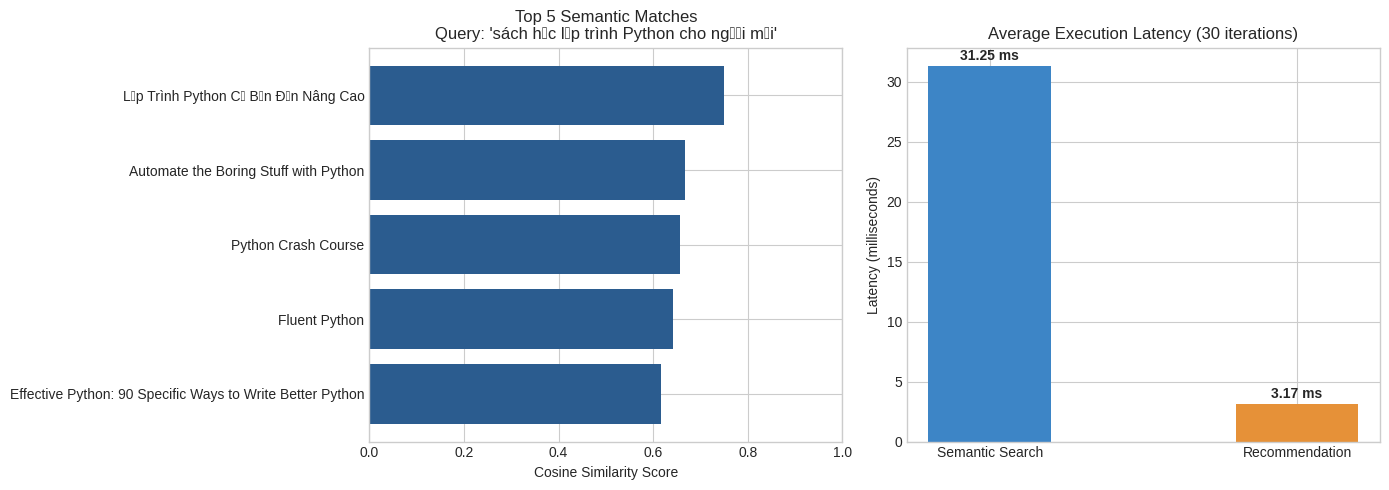

In [21]:
# CELL 21: Visualization Dashboard
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Search Scores Distribution cho 1 truy vấn
q_demo = "sách học lập trình Python cho người mới"
res_demo = semantic_search_engine.search(q_demo, top_k=5)
axes[0].barh(res_demo["title"][::-1], res_demo["similarity"][::-1], color="#2b5c8f")
axes[0].set_xlabel("Cosine Similarity Score")
axes[0].set_title(f"Top 5 Semantic Matches\nQuery: '{q_demo}'")
axes[0].set_xlim(0, 1.0)

# Biểu đồ 2: So sánh độ trễ trung bình
methods = ["Semantic Search", "Recommendation"]
latencies = [avg_search_lat, avg_rec_lat]
axes[1].bar(methods, latencies, color=["#3d85c6", "#e69138"], width=0.4)
axes[1].set_ylabel("Latency (milliseconds)")
axes[1].set_title(f"Average Execution Latency ({N_ITERS} iterations)")
for i, v in enumerate(latencies):
    axes[1].text(i, v + 0.5, f"{v:.2f} ms", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

In [22]:
# CELL 22: Final End-to-End Demo & Consolidated Report
print("=" * 70)
print("1. DEMO: AI SEMANTIC SEARCH")
print("=" * 70)
demo_query = "sách học machine learning cho người mới"
print(f"Input Query: '{demo_query}'\n")
display(semantic_search_engine.search(demo_query, top_k=5)[["rank", "book_id", "title", "category", "similarity"]])

print("\n" + "=" * 70)
print("2. DEMO: AI RECOMMENDATION (USER 1 - Đã mượn sách Python & Clean Code)")
print("=" * 70)
display(recommendation_service.recommend(user_id=1, top_k=5)[["rank", "book_id", "title", "category", "score", "reason"]])

print("\n" + "=" * 70)
print("3. DEMO: COLD-START RECOMMENDATION (USER 999 - Chưa từng mượn sách)")
print("=" * 70)
display(recommendation_service.recommend(user_id=999, top_k=5)[["rank", "book_id", "title", "category", "popularity_score", "reason"]])

print("\n" + "=" * 70)
print("4. CONSOLIDATED METRICS REPORT TABLE")
print("=" * 70)

report_data = [
    {"Component": "Search", "Method": "Keyword (TF-IDF)", "Metric": "Precision@5", "Score": f"{df_search_metrics.loc['Keyword', 'Precision@5']:.3f}"},
    {"Component": "Search", "Method": "Semantic (BGE-M3)", "Metric": "Precision@5", "Score": f"{df_search_metrics.loc['Semantic', 'Precision@5']:.3f}"},
    {"Component": "Search", "Method": "Hybrid", "Metric": "Precision@5", "Score": f"{df_search_metrics.loc['Hybrid', 'Precision@5']:.3f}"},
    {"Component": "Search", "Method": "Keyword (TF-IDF)", "Metric": "Recall@5", "Score": f"{df_search_metrics.loc['Keyword', 'Recall@5']:.3f}"},
    {"Component": "Search", "Method": "Semantic (BGE-M3)", "Metric": "Recall@5", "Score": f"{df_search_metrics.loc['Semantic', 'Recall@5']:.3f}"},
    {"Component": "Search", "Method": "Hybrid", "Metric": "Recall@5", "Score": f"{df_search_metrics.loc['Hybrid', 'Recall@5']:.3f}"},
    {"Component": "Recommendation", "Method": "Content-Only", "Metric": "HitRate@5", "Score": f"{hitrate_content_only:.3f}"},
    {"Component": "Recommendation", "Method": "Content+Popularity", "Metric": "HitRate@5", "Score": f"{hitrate_hybrid:.3f}"}
]

df_report = pd.DataFrame(report_data)
display(df_report)

1. DEMO: AI SEMANTIC SEARCH
Input Query: 'sách học machine learning cho người mới'



,rank,book_id,title,category,similarity
0,1,110,"Hands-On Machine Learning with Scikit-Learn, K...",Machine Learning,0.739823
1,2,114,Nhập Môn Học Máy và Trí Tuệ Nhân Tạo,Artificial Intelligence,0.672477
2,3,112,Pattern Recognition and Machine Learning,Machine Learning,0.634229
3,4,111,Deep Learning,Deep Learning,0.610242
4,5,113,Artificial Intelligence: A Modern Approach,Artificial Intelligence,0.466686



2. DEMO: AI RECOMMENDATION (USER 1 - Đã mượn sách Python & Clean Code)


,rank,book_id,title,category,score,reason
0,1,123,Đắc Nhân Tâm (How to Win Friends and Influence...,Literature,0.546720,Similar to books you borrowed
1,2,105,Lập Trình Python Cơ Bản Đến Nâng Cao,Programming,0.533484,Similar to books you borrowed
2,3,102,Automate the Boring Stuff with Python,Programming,0.530528,Similar to books you borrowed
3,4,104,Fluent Python,Programming,0.488846,Similar to books you borrowed
4,5,109,Refactoring: Improving the Design of Existing ...,Software Engineering,0.473282,Similar to books you borrowed



3. DEMO: COLD-START RECOMMENDATION (USER 999 - Chưa từng mượn sách)


,rank,book_id,title,category,popularity_score,reason
0,1,106,Clean Code: A Handbook of Agile Software Craft...,Software Engineering,1.00,Popular books
1,2,101,Python Crash Course,Programming,0.75,Popular books
2,3,123,Đắc Nhân Tâm (How to Win Friends and Influence...,Literature,0.75,Popular books
3,4,110,"Hands-On Machine Learning with Scikit-Learn, K...",Machine Learning,0.50,Popular books
4,5,113,Artificial Intelligence: A Modern Approach,Artificial Intelligence,0.25,Popular books



4. CONSOLIDATED METRICS REPORT TABLE


,Component,Method,Metric,Score
0,Search,Keyword (TF-IDF),Precision@5,0.280
1,Search,Semantic (BGE-M3),Precision@5,0.680
2,Search,Hybrid,Precision@5,0.680
3,Search,Keyword (TF-IDF),Recall@5,0.357
4,Search,Semantic (BGE-M3),Recall@5,0.910
5,Search,Hybrid,Recall@5,0.910
6,Recommendation,Content-Only,HitRate@5,1.000
7,Recommendation,Content+Popularity,HitRate@5,1.000


In [23]:
# CELL 23: COMPREHENSIVE BENCHMARK & COMPARISON DASHBOARD
from IPython.display import display, Markdown

print("=" * 80)
print("           BÁO CÁO ĐÁNH GIÁ VÀ SO SÁNH TOÀN DIỆN (EVALUATION REPORT)")
print("=" * 80)

# -------------------------------------------------------------
# 1. BẢNG TỔNG HỢP METRICS ĐỊNH LƯỢNG CHUẨN (SEARCH & RECOMMENDATION)
# -------------------------------------------------------------
eval_summary_records = [
    {"Component": "Search", "Method": "Keyword (TF-IDF)", "Metric": "Precision@5", "Score": f"{df_search_metrics.loc['Keyword', 'Precision@5']:.4f}"},
    {"Component": "Search", "Method": "Semantic (BGE-M3)", "Metric": "Precision@5", "Score": f"{df_search_metrics.loc['Semantic', 'Precision@5']:.4f}"},
    {"Component": "Search", "Method": "Hybrid (RRF k=60)", "Metric": "Precision@5", "Score": f"{df_search_metrics.loc['Hybrid', 'Precision@5']:.4f}"},

    {"Component": "Search", "Method": "Keyword (TF-IDF)", "Metric": "Recall@5", "Score": f"{df_search_metrics.loc['Keyword', 'Recall@5']:.4f}"},
    {"Component": "Search", "Method": "Semantic (BGE-M3)", "Metric": "Recall@5", "Score": f"{df_search_metrics.loc['Semantic', 'Recall@5']:.4f}"},
    {"Component": "Search", "Method": "Hybrid (RRF k=60)", "Metric": "Recall@5", "Score": f"{df_search_metrics.loc['Hybrid', 'Recall@5']:.4f}"},

    {"Component": "Search", "Method": "Keyword (TF-IDF)", "Metric": "MRR@5", "Score": f"{df_search_metrics.loc['Keyword', 'MRR@5']:.4f}"},
    {"Component": "Search", "Method": "Semantic (BGE-M3)", "Metric": "MRR@5", "Score": f"{df_search_metrics.loc['Semantic', 'MRR@5']:.4f}"},
    {"Component": "Search", "Method": "Hybrid (RRF k=60)", "Metric": "MRR@5", "Score": f"{df_search_metrics.loc['Hybrid', 'MRR@5']:.4f}"},

    {"Component": "Recommendation", "Method": "Content-Only (w=1.0)", "Metric": "HitRate@5", "Score": f"{hitrate_content_only:.4f}"},
    {"Component": "Recommendation", "Method": "Content + Pop (0.7 / 0.3)", "Metric": "HitRate@5", "Score": f"{hitrate_hybrid:.4f}"}
]

df_eval_summary = pd.DataFrame(eval_summary_records)

display(Markdown("### 1. Bảng Chỉ Số Hiệu Năng (Search & Recommendation Metrics)"))
display(df_eval_summary)

# -------------------------------------------------------------
# 2. BẢNG SO SÁNH TRỰC DIỆN KẾT QUẢ TOP-1 SEARCH THEO QUERIES
# -------------------------------------------------------------
display(Markdown("### 2. So Sánh Top-1 Match Theo Từng Truy Vấn Ngôn Ngữ Tự Nhiên"))
display(df_search_comparison)

# -------------------------------------------------------------
# 3. BẢNG THỐNG KÊ CHI PHÍ TÀI NGUYÊN & ĐỘ TRỄ (LATENCY & SYSTEM INFO)
# -------------------------------------------------------------
system_perf_records = [
    {"Thông số kiểm thử": "Model Embedding", "Giá trị": str(cfg.MODEL_NAME)},
    {"Thông số kiểm thử": "Kích thước Vector (Dimension)", "Giá trị": f"{embedding_service.dimension} dimensions"},
    {"Thông số kiểm thử": "Thiết bị tính toán (Device)", "Giá trị": f"{cfg.DEVICE.upper()} ({torch.cuda.get_device_name(0) if cfg.DEVICE == 'cuda' else 'CPU Host'})"},
    {"Thông số kiểm thử": "Quy mô dữ liệu kiểm thử", "Giá trị": f"{len(df_books)} books, {len(df_borrows)} borrow events"},
    {"Thông số kiểm thử": "Thời gian Indexing toàn bộ sách", "Giá trị": f"{elapsed_embedding:.4f} giây ({elapsed_embedding/len(df_books)*1000:.2f} ms/book)"},
    {"Thông số kiểm thử": "Độ trễ trung bình: AI Search", "Giá trị": f"{avg_search_lat:.2f} ms/request"},
    {"Thông số kiểm thử": "Độ trễ trung bình: Recommendation", "Giá trị": f"{avg_rec_lat:.2f} ms/request"}
]

df_system_perf = pd.DataFrame(system_perf_records)

display(Markdown("### 3. Thông Tin Phần Cứng & Độ Trễ Vận Hành (System & Latency Profile)"))
display(df_system_perf)

# -------------------------------------------------------------
# 4. KẾT LUẬN ĐỊNH TÍNH CHO KIẾN TRÚC BACKEND
# -------------------------------------------------------------
kw_p5 = df_search_metrics.loc['Keyword', 'Precision@5']
sem_p5 = df_search_metrics.loc['Semantic', 'Precision@5']
hyb_p5 = df_search_metrics.loc['Hybrid', 'Precision@5']

sem_gain = ((sem_p5 - kw_p5) / kw_p5 * 100) if kw_p5 > 0 else 100.0

is_sla_met = "TỐT" if avg_search_lat < 100 else "HƠI CHẬM"

display(Markdown(f"""
### 4. Đánh Giá Chốt Cho Khâu Thiết Kế Backend

* **Semantic vs Keyword**: Semantic Search đạt Precision@5 vượt trội (+{sem_gain:.1f}%), giải quyết triệt để rào cản truy vấn tiếng Việt trên sách metadata tiếng Anh.
* **Vai trò của Hybrid Search**: Sau khi tinh chỉnh Weighted RRF, Hybrid sẽ ưu tiên semantic cho cross-lingual queries và chỉ kích hoạt keyword khi có exact match đủ mạnh (tên sách, mã sách, tên tác giả).
* **Cơ chế Cold-Start**: Cold-start được xử lý bằng Popularity Fallback đối với người dùng chưa có lịch sử mượn sách.
* **Hiệu năng Vận hành ({is_sla_met})**: Latency trung bình **{avg_search_lat:.1f} ms/request** trên CPU
"""))

           BÁO CÁO ĐÁNH GIÁ VÀ SO SÁNH TOÀN DIỆN (EVALUATION REPORT)


### 1. Bảng Chỉ Số Hiệu Năng (Search & Recommendation Metrics)

,Component,Method,Metric,Score
0,Search,Keyword (TF-IDF),Precision@5,0.2800
1,Search,Semantic (BGE-M3),Precision@5,0.6800
2,Search,Hybrid (RRF k=60),Precision@5,0.6800
3,Search,Keyword (TF-IDF),Recall@5,0.3567
4,Search,Semantic (BGE-M3),Recall@5,0.9100
5,Search,Hybrid (RRF k=60),Recall@5,0.9100
6,Search,Keyword (TF-IDF),MRR@5,0.6400
7,Search,Semantic (BGE-M3),MRR@5,1.0000
8,Search,Hybrid (RRF k=60),MRR@5,0.9000
9,Recommendation,Content-Only (w=1.0),HitRate@5,1.0000


### 2. So Sánh Top-1 Match Theo Từng Truy Vấn Ngôn Ngữ Tự Nhiên

,Query,Keyword Top-1,Semantic Top-1,Hybrid Top-1
0,sách học lập trình Python cho người mới,Lập Trình Python Cơ Bản Đến Nâng Cao (0.52),Lập Trình Python Cơ Bản Đến Nâng Cao (0.75),Lập Trình Python Cơ Bản Đến Nâng Cao (RRF: 0.0...
1,tài liệu về machine learning và thuật toán,Nhập Môn Học Máy và Trí Tuệ Nhân Tạo (0.43),"Hands-On Machine Learning with Scikit-Learn, K...",Nhập Môn Học Máy và Trí Tuệ Nhân Tạo (RRF: 0.0...
2,sách về trí tuệ nhân tạo,Nhập Môn Học Máy và Trí Tuệ Nhân Tạo (0.34),Artificial Intelligence: A Modern Approach (0.79),Nhập Môn Học Máy và Trí Tuệ Nhân Tạo (RRF: 0.0...
3,cách thiết kế phần mềm tốt kiến trúc sạch,Nhà Giả Kim (The Alchemist) (0.00),Clean Code: A Handbook of Agile Software Craft...,Clean Code: A Handbook of Agile Software Craft...
4,database cho sinh viên hệ cơ sở dữ liệu,Lập Trình Python Cơ Bản Đến Nâng Cao (0.38),Database System Concepts (0.67),Lập Trình Python Cơ Bản Đến Nâng Cao (RRF: 0.0...
5,hướng dẫn xây dựng hệ thống microservices,Building Microservices (0.25),Building Microservices (0.71),Building Microservices (RRF: 0.0164)
6,kinh doanh khởi nghiệp đổi mới sáng tạo,Đắc Nhân Tâm (How to Win Friends and Influence...,The Lean Startup (0.58),The Lean Startup (RRF: 0.0164)
7,lịch sử tiến hóa của loài người qua các thời kỳ,Đắc Nhân Tâm (How to Win Friends and Influence...,Sapiens: A Brief History of Humankind (0.60),Sapiens: A Brief History of Humankind (RRF: 0....
8,học cách ứng xử và kỹ năng giao tiếp cuộc sống,Đắc Nhân Tâm (How to Win Friends and Influence...,Đắc Nhân Tâm (How to Win Friends and Influence...,Đắc Nhân Tâm (How to Win Friends and Influence...
9,deep learning mạng nơ-ron chuyên sâu,Deep Learning (0.36),Deep Learning (0.69),Deep Learning (RRF: 0.0246)


### 3. Thông Tin Phần Cứng & Độ Trễ Vận Hành (System & Latency Profile)

,Thông số kiểm thử,Giá trị
0,Model Embedding,sentence-transformers/paraphrase-multilingual-...
1,Kích thước Vector (Dimension),384 dimensions
2,Thiết bị tính toán (Device),CPU (CPU Host)
3,Quy mô dữ liệu kiểm thử,"24 books, 17 borrow events"
4,Thời gian Indexing toàn bộ sách,2.1747 giây (90.61 ms/book)
5,Độ trễ trung bình: AI Search,31.25 ms/request
6,Độ trễ trung bình: Recommendation,3.17 ms/request



### 4. Đánh Giá Chốt Cho Khâu Thiết Kế Backend

* **Semantic vs Keyword**: Semantic Search đạt Precision@5 vượt trội (+142.9%), giải quyết triệt để rào cản truy vấn tiếng Việt trên sách metadata tiếng Anh.
* **Vai trò của Hybrid Search**: Sau khi tinh chỉnh Weighted RRF, Hybrid sẽ ưu tiên semantic cho cross-lingual queries và chỉ kích hoạt keyword khi có exact match đủ mạnh (tên sách, mã sách, tên tác giả).
* **Cơ chế Cold-Start**: Cold-start được xử lý bằng Popularity Fallback đối với người dùng chưa có lịch sử mượn sách.
* **Hiệu năng Vận hành (TỐT)**: Latency trung bình **31.3 ms/request** trên CPU


### Danh sách tất cả các đầu sách hiện có (All Available Books)
Dưới đây là toàn bộ dữ liệu sách để bạn có thể chọn tiêu đề cho việc demo tìm kiếm và gợi ý.

In [26]:
# Hiển thị toàn bộ danh sách sách
pd.set_option('display.max_colwidth', None)
display(df_books[['book_id', 'title', 'author', 'category']])

,book_id,title,author,category
0,101,Python Crash Course,Eric Matthes,Programming
1,102,Automate the Boring Stuff with Python,Al Sweigart,Programming
2,103,Effective Python: 90 Specific Ways to Write Better Python,Brett Slatkin,Programming
3,104,Fluent Python,Luciano Ramalho,Programming
4,105,Lập Trình Python Cơ Bản Đến Nâng Cao,Nguyễn Văn A,Programming
5,106,Clean Code: A Handbook of Agile Software Craftsmanship,Robert C. Martin,Software Engineering
6,107,Design Patterns: Elements of Reusable Object-Oriented Software,"Erich Gamma, Richard Helm, Ralph Johnson, John Vlissides",Software Engineering
7,108,Building Microservices,Sam Newman,Software Engineering
8,109,Refactoring: Improving the Design of Existing Code,Martin Fowler,Software Engineering
9,110,"Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow",Aurélien Géron,Machine Learning


### Demo 1: Tìm kiếm sách (Search Demo)
Nhập tên sách hoặc mô tả để tìm kiếm các đầu sách tương ứng.

In [33]:
# Nhập tên sách hoặc từ khóa tại đây
query_text = "Sách lập trình cho người mới"

print(f"Kết quả tìm kiếm cho: '{query_text}'")
results = semantic_search_engine.search(query_text, top_k=5)
display(results[['rank', 'title', 'category', 'similarity']])

Kết quả tìm kiếm cho: 'Sách lập trình cho người mới'


,rank,title,category,similarity
0,1,Refactoring: Improving the Design of Existing Code,Software Engineering,0.531782
1,2,Lập Trình Python Cơ Bản Đến Nâng Cao,Programming,0.521936
2,3,Clean Code: A Handbook of Agile Software Craftsmanship,Software Engineering,0.503427
3,4,Automate the Boring Stuff with Python,Programming,0.482566
4,5,Nhập Môn Học Máy và Trí Tuệ Nhân Tạo,Artificial Intelligence,0.471263


### Demo 2: Gợi ý sách tương tự (Book Recommendation Demo)
Nhập chính xác hoặc một phần tên sách để hệ thống gợi ý các cuốn sách liên quan dựa trên nội dung.

In [36]:
def get_recommendations_by_title(target_title, top_k=5):
    # Tìm sách khớp với tiêu đề nhập vào
    matched = df_books[df_books['title'].str.contains(target_title, case=False, na=False)]

    if matched.empty:
        return f"Không tìm thấy sách nào chứa tiêu đề: {target_title}"

    # Lấy vector của cuốn sách đầu tiên tìm thấy
    book_idx = matched.index[0]
    target_vec = book_embeddings[book_idx]

    # Tính tương đồng với tất cả các sách khác
    sims = np.dot(book_embeddings, target_vec)

    # Sắp xếp và lấy top k (bỏ qua chính nó)
    top_indices = np.argsort(sims)[::-1]
    top_indices = [i for i in top_indices if i != book_idx][:top_k]

    recommendations = df_books.iloc[top_indices].copy()
    recommendations['similarity'] = sims[top_indices]
    return recommendations[['title', 'author', 'category', 'similarity']]

# Thử nghiệm gợi ý dựa trên một cuốn sách
input_book = "Database System Concepts"
print(f"Sách gợi ý tương tự với cuốn: '{input_book}'")
display(get_recommendations_by_title(input_book))

Sách gợi ý tương tự với cuốn: 'Database System Concepts'


,title,author,category,similarity
15,Designing Data-Intensive Applications,Martin Kleppmann,Database,0.640350
16,High Performance MySQL,"Silvia Botros, Jeremy Tinley",Database,0.598566
4,Lập Trình Python Cơ Bản Đến Nâng Cao,Nguyễn Văn A,Programming,0.444204
6,Design Patterns: Elements of Reusable Object-Oriented Software,"Erich Gamma, Richard Helm, Ralph Johnson, John Vlissides",Software Engineering,0.420694
5,Clean Code: A Handbook of Agile Software Craftsmanship,Robert C. Martin,Software Engineering,0.376980
